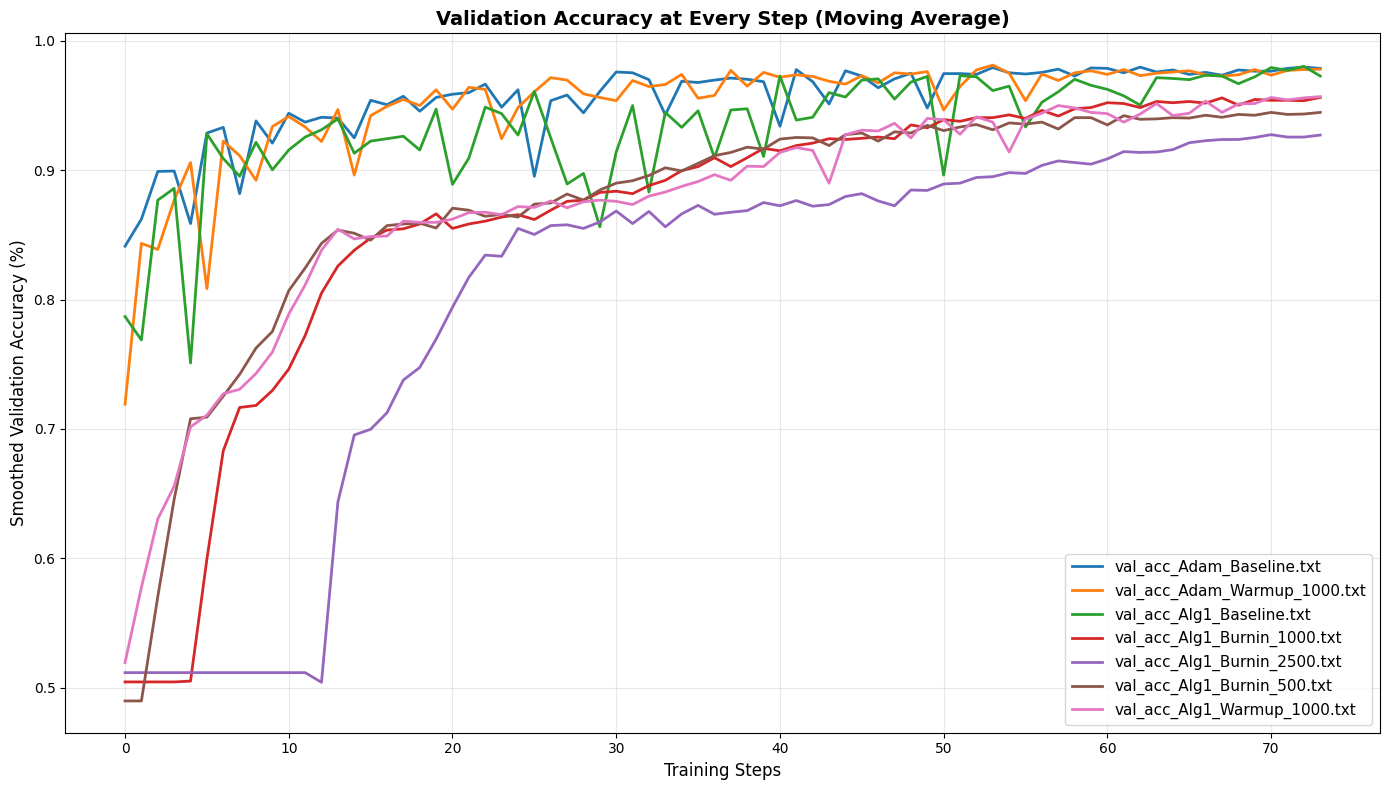

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, window_size=50):
    valid_points = points[~np.isnan(points)]
    
    if len(valid_points) < window_size:
        return valid_points
        
    smoothed_points = np.convolve(valid_points, np.ones(window_size)/window_size, mode='valid')
    return smoothed_points

plt.figure(figsize=(14, 8))

valacc = []
valnames = []
for name in os.listdir("../results/burnin_ourdata/val_acc/"):
    try:
        val_acc_data = np.loadtxt(f"../results/burnin_ourdata/val_acc/{name}")
        
        smoothed_acc = smooth_curve(val_acc_data, window_size=100)
        steps_x = np.arange(len(smoothed_acc))

        valacc.append(val_acc_data)
        valnames.append(name)
        
        plt.plot(steps_x, smoothed_acc, label=f"{name}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Validation Accuracy (%)", fontsize=12)
plt.title("Validation Accuracy at Every Step (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.xlim(0, 3000)
plt.savefig('val_accuracy_smoothed_zoom.png', dpi=300)
plt.show()

In [6]:
import pandas as pd

In [12]:
valaccdf = pd.DataFrame(valacc, index=valnames).T

In [15]:
summary_valacc = valaccdf.describe()
styler = summary_valacc.style.format(precision=3)
latex_code = styler.to_latex(hrules=True)  # hrules=True gives \toprule \midrule \bottomrule
print(latex_code)

\begin{tabular}{lrrrrrrr}
\toprule
 & val_acc_Adam_Baseline.txt & val_acc_Adam_Warmup_1000.txt & val_acc_Alg1_Baseline.txt & val_acc_Alg1_Burnin_1000.txt & val_acc_Alg1_Burnin_2500.txt & val_acc_Alg1_Burnin_500.txt & val_acc_Alg1_Warmup_1000.txt \\
\midrule
count & 74.000 & 74.000 & 74.000 & 74.000 & 74.000 & 74.000 & 74.000 \\
mean & 0.955 & 0.951 & 0.933 & 0.864 & 0.802 & 0.874 & 0.874 \\
std & 0.030 & 0.044 & 0.045 & 0.121 & 0.147 & 0.098 & 0.092 \\
min & 0.841 & 0.719 & 0.751 & 0.504 & 0.504 & 0.490 & 0.519 \\
25% & 0.945 & 0.948 & 0.914 & 0.856 & 0.753 & 0.859 & 0.860 \\
50% & 0.968 & 0.966 & 0.945 & 0.906 & 0.869 & 0.912 & 0.892 \\
75% & 0.975 & 0.974 & 0.967 & 0.942 & 0.898 & 0.935 & 0.940 \\
max & 0.980 & 0.981 & 0.980 & 0.956 & 0.927 & 0.945 & 0.957 \\
\bottomrule
\end{tabular}



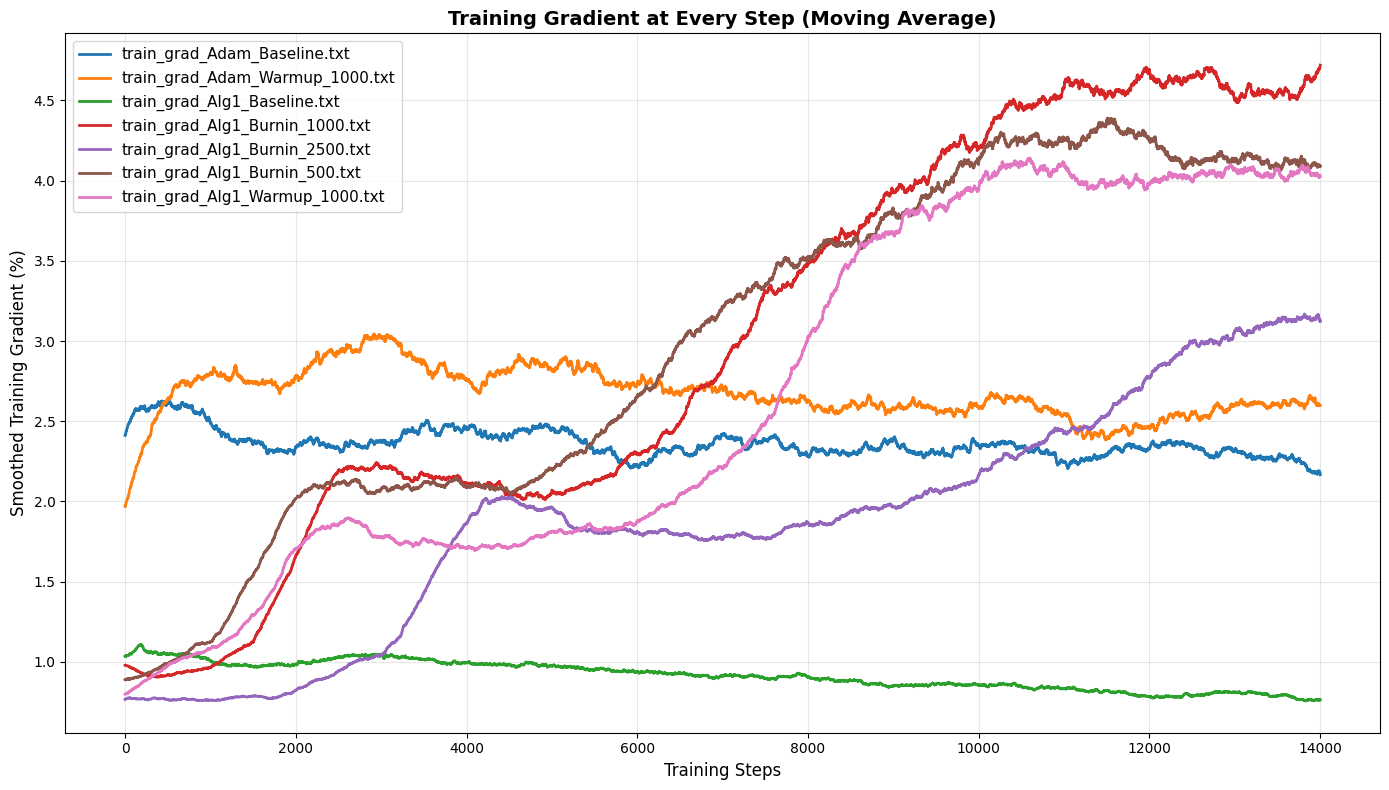

In [16]:
plt.figure(figsize=(14, 8))

traingrad = []
gradname = []

for name in os.listdir("../results/burnin_ourdata/train_grad/"):
    try:
        train_acc_data = np.loadtxt(f"../results/burnin_ourdata/train_grad/{name}")
        
        smoothed_acc = smooth_curve(train_acc_data, window_size=1000)
        steps_x = np.arange(len(smoothed_acc))

        traingrad.append(train_acc_data)
        gradname.append(name)
        
        plt.plot(steps_x, smoothed_acc, label=f"{name}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Training Gradient (%)", fontsize=12)
plt.title("Training Gradient at Every Step (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.xlim(0, 3000)
# plt.savefig('train_gradient_smoothed_zoom.png', dpi=300)
plt.show()

In [17]:
graddf = pd.DataFrame(traingrad, index=gradname).T
summary_grad = graddf.describe()

In [18]:
styler = summary_grad.style.format(precision=3)
latex_code = styler.to_latex(hrules=True)  # hrules=True gives \toprule \midrule \bottomrule
print(latex_code)

\begin{tabular}{lrrrrrrr}
\toprule
 & train_grad_Adam_Baseline.txt & train_grad_Adam_Warmup_1000.txt & train_grad_Alg1_Baseline.txt & train_grad_Alg1_Burnin_1000.txt & train_grad_Alg1_Burnin_2500.txt & train_grad_Alg1_Burnin_500.txt & train_grad_Alg1_Warmup_1000.txt \\
\midrule
count & 15000.000 & 15000.000 & 15000.000 & 15000.000 & 15000.000 & 15000.000 & 15000.000 \\
mean & 2.349 & 2.639 & 0.912 & 3.015 & 1.879 & 2.963 & 2.652 \\
std & 1.802 & 2.114 & 0.640 & 2.461 & 1.436 & 2.427 & 2.138 \\
min & 0.002 & 0.003 & 0.001 & 0.196 & 0.227 & 0.236 & 0.222 \\
25% & 1.020 & 1.083 & 0.445 & 1.235 & 0.876 & 1.225 & 1.141 \\
50% & 1.862 & 2.048 & 0.744 & 2.269 & 1.417 & 2.210 & 2.014 \\
75% & 3.157 & 3.589 & 1.212 & 4.005 & 2.457 & 3.940 & 3.441 \\
max & 14.389 & 20.578 & 8.185 & 22.234 & 12.817 & 20.418 & 17.382 \\
\bottomrule
\end{tabular}



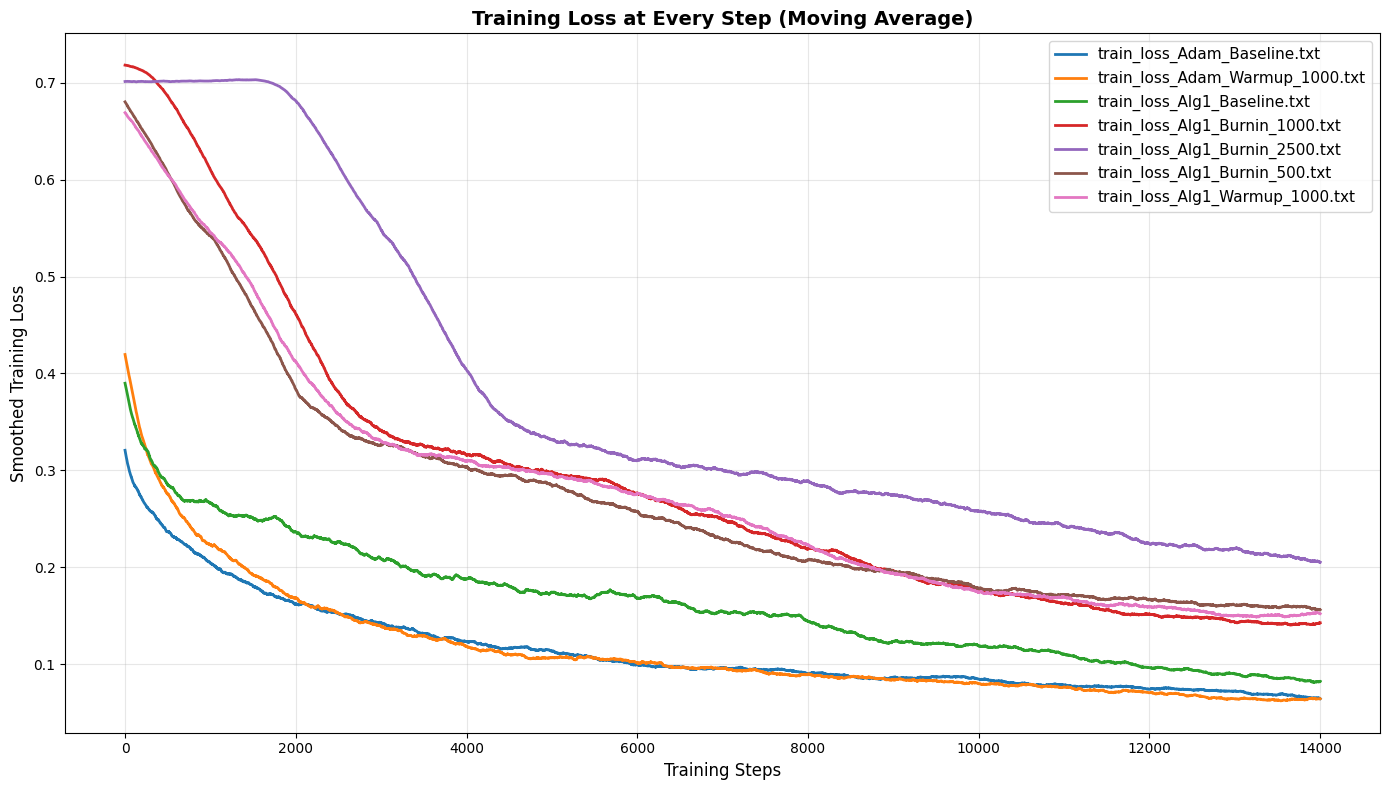

In [19]:
plt.figure(figsize=(14, 8))

trainloss = []
for name in os.listdir("../results/burnin_ourdata/train_loss/"):
    try:
        train_acc_data = np.loadtxt(f"../results/burnin_ourdata/train_loss/{name}")
        
        smoothed_acc = smooth_curve(train_acc_data, window_size=1000)
        steps_x = np.arange(len(smoothed_acc))

        trainloss.append(train_acc_data)
        
        plt.plot(steps_x, smoothed_acc, label=f"{name}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Training Loss", fontsize=12)
plt.title("Training Loss at Every Step (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.xlim(0, 3000)
# plt.savefig('train_loss_smoothed_zoom.png', dpi=300)
plt.show()

In [20]:
lossdf = pd.DataFrame(trainloss).T 
summary_loss = lossdf.describe()

In [21]:
styler = summary_loss.style.format(precision=3)
latex_code = styler.to_latex(hrules=True)  # hrules=True gives \toprule \midrule \bottomrule
print(latex_code)

\begin{tabular}{lrrrrrrr}
\toprule
 & 0 & 1 & 2 & 3 & 4 & 5 & 6 \\
\midrule
count & 15000.000 & 15000.000 & 15000.000 & 15000.000 & 15000.000 & 15000.000 & 15000.000 \\
mean & 0.121 & 0.127 & 0.170 & 0.297 & 0.379 & 0.283 & 0.287 \\
std & 0.098 & 0.119 & 0.124 & 0.190 & 0.197 & 0.171 & 0.171 \\
min & 0.000 & 0.000 & 0.000 & 0.009 & 0.030 & 0.011 & 0.009 \\
25% & 0.053 & 0.049 & 0.083 & 0.155 & 0.224 & 0.157 & 0.158 \\
50% & 0.095 & 0.093 & 0.140 & 0.247 & 0.320 & 0.240 & 0.248 \\
75% & 0.160 & 0.162 & 0.223 & 0.388 & 0.537 & 0.363 & 0.376 \\
max & 0.839 & 0.842 & 0.909 & 0.832 & 0.856 & 0.902 & 0.824 \\
\bottomrule
\end{tabular}



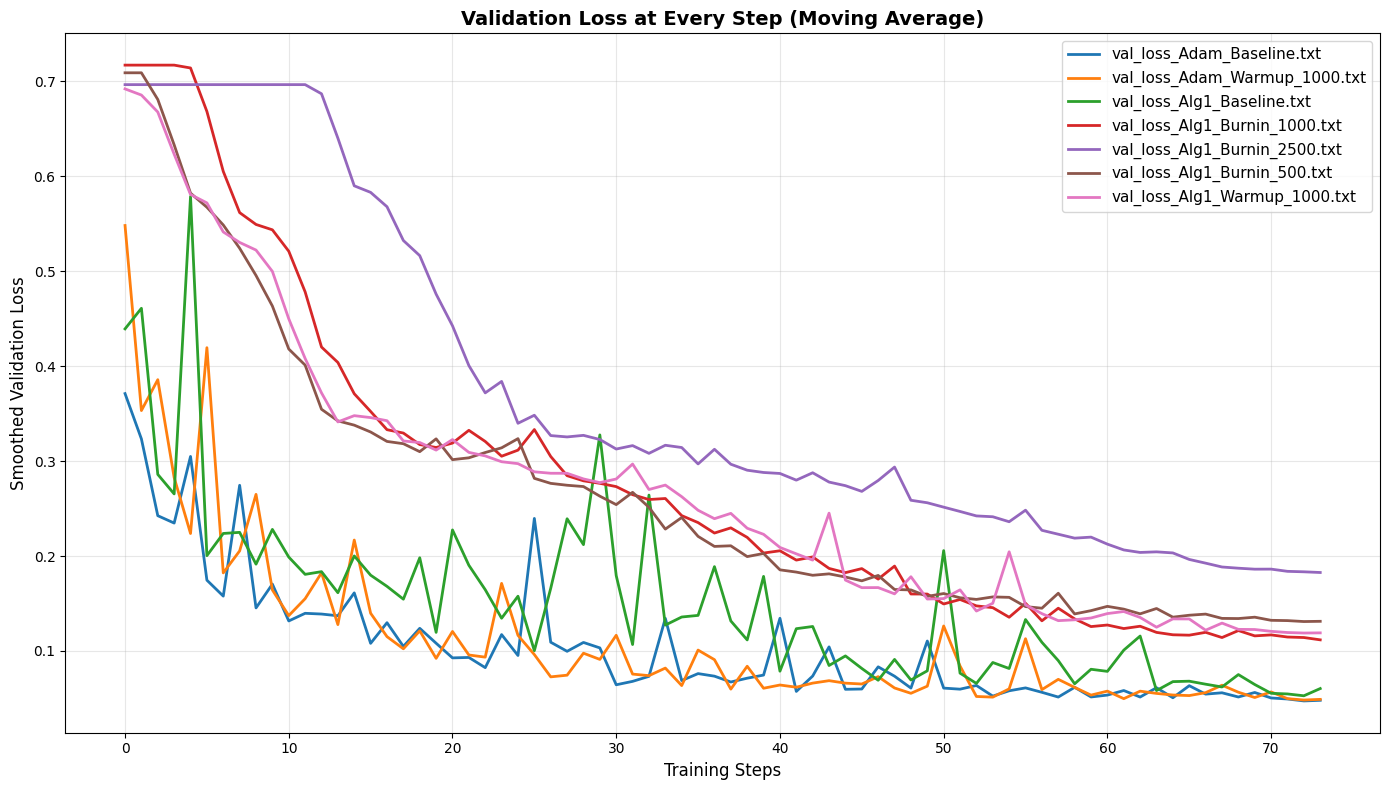

In [11]:
plt.figure(figsize=(14, 8))

for name in os.listdir("../results/burnin_ourdata/val_loss/"):
    try:
        train_acc_data = np.loadtxt(f"../results/burnin_ourdata/val_loss/{name}")
        
        smoothed_acc = smooth_curve(train_acc_data, window_size=1000)
        steps_x = np.arange(len(smoothed_acc))
        
        plt.plot(steps_x, smoothed_acc, label=f"{name}", linewidth=2)
    except FileNotFoundError:
        pass

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Smoothed Validation Loss", fontsize=12)
plt.title("Validation Loss at Every Step (Moving Average)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.xlim(0, 3000)
# plt.savefig('val_loss_smoothed_zoom.png', dpi=300)
plt.show()